In [4]:
%load_ext autoreload
%autoreload 2

import sys
import os

sys.path.append(os.path.abspath(".."))
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from src.airfoil_predictor import AirfoilAI

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
ai = AirfoilAI("../data/airfoil_optimization_results.csv")
v_test, alt_test = 164, 3102
naca_ideal = ai.predict_naca(v_test, alt_test)

print(f"For V={v_test}m/s and Alt={alt_test}m, ai predicts NACA : {naca_ideal}")

ai.save_model()

L'IA a fini son entraînement sur le dataset.
For V=164m/s and Alt=3102m, ai predicts NACA : 9605


L'IA a fini son entraînement sur le dataset.


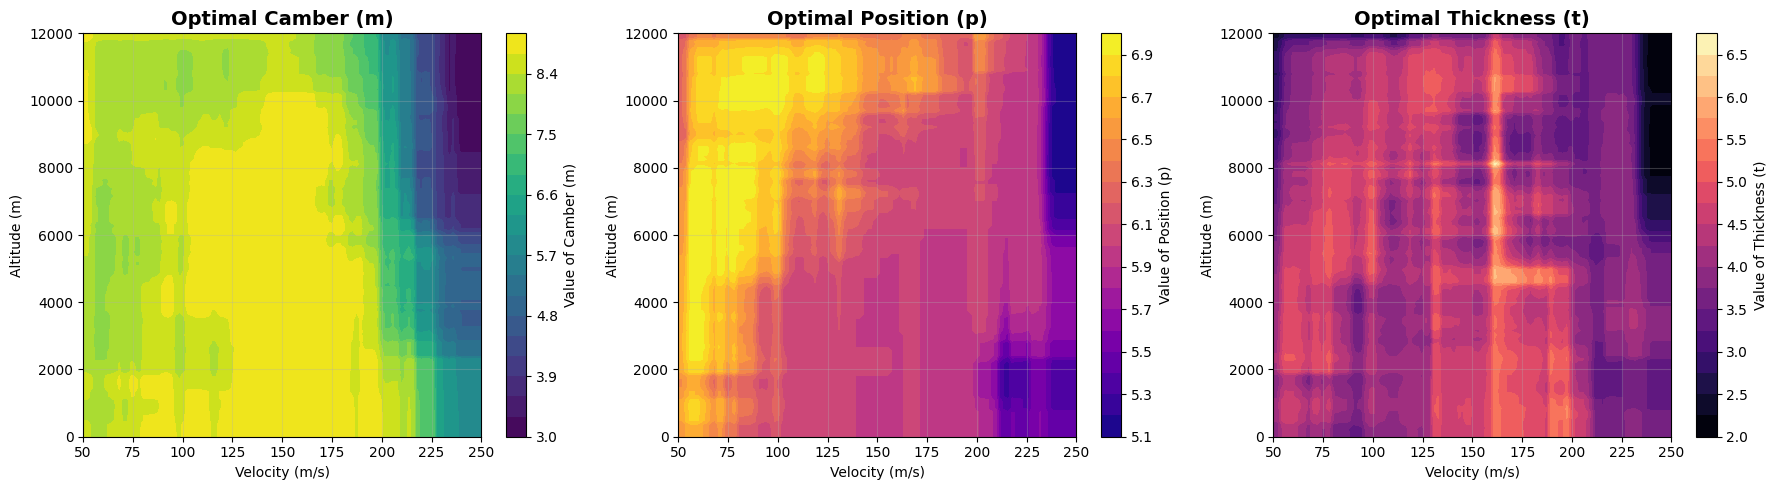

In [6]:
# 1. Setup Data and AI
ai = AirfoilAI("../data/airfoil_optimization_results.csv")
v_range = np.linspace(50, 250, 100)
alt_range = np.linspace(0, 12000, 100)
V, ALT = np.meshgrid(v_range, alt_range)

# 2. Predict all parameters
grid_points = np.c_[V.ravel(), ALT.ravel()]
df_grid = pd.DataFrame(grid_points, columns=['velocity', 'altitude'])
predictions = ai.model.predict(df_grid)

# 3. Create the 3-Panel Figure
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
param_names = ['Camber (m)', 'Position (p)', 'Thickness (t)']
colormaps = ['viridis', 'plasma', 'magma'] # Distinct colors for each parameter

for i in range(3):
    # Extract M (index 0), P (index 1), or T (index 2)
    Z = predictions[:, i].reshape(V.shape)
    
    # Create the contour plot
    cp = axs[i].contourf(V, ALT, Z, levels=20, cmap=colormaps[i])
    fig.colorbar(cp, ax=axs[i], label=f'Value of {param_names[i]}')
    
    # Add labels and formatting
    axs[i].set_title(f"Optimal {param_names[i]}", fontsize=14, fontweight='bold')
    axs[i].set_xlabel("Velocity (m/s)")
    axs[i].set_ylabel("Altitude (m)")
    axs[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()